## Problem Statement - Product Segmentation

### Context
When you think of sneakers for a trip, the importance of good footwear cannot be discarded, and the obvious brands that come to mind are Adidas and Nike. Adidas vs Nike is a constant debate as the two giants in the apparel market, with a large market cap and market share, battle it out to come on top. As a newly hired Data Scientist in a market research company, you have been given the task of extracting insights from the data of men's and women's shoes, and grouping products together to identify similarities and differences between the product range of these renowned brands.

 

### Objective
To perform an exploratory data analysis and cluster the products based on various factors.

### Key Questions
- Which variables are most important for clustering?
- How each cluster is different from the others?
- What are the business recommendations?
 

### Data Description
The dataset consists of 3268 products from Nike and Adidas with features of information including their ratings, discount, sales price, listed price, product name, and the number of reviews.

- Product Name: Name of the product
- Product ID: ID of the product
- Listing Price: Listed price of the product
- Sale Price: Sale price of the product
- Discount: Percentage of discount on the product
- Brand: Brand of the product
- Rating: Rating of the product
- Reviews: Number of reviews for the product

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns.set_theme()

from scipy.stats import zscore
from scipy.spatial.distance import cdist

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

In [2]:
data = pd.read_csv("data_add_nik.csv")
data.shape

(3268, 8)

In [3]:
data.head()

,Product Name,Product ID,Listing Price,Sale Price,Discount,Brand,Rating,Reviews
0,Women's adidas Originals NMD_Racer Primeknit S...,AH2430,14999,7499,50,Adidas Adidas ORIGINALS,4.8,41
1,Women's adidas Originals Sleek Shoes,G27341,7599,3799,50,Adidas ORIGINALS,3.3,24
2,Women's adidas Swim Puka Slippers,CM0081,999,599,40,Adidas CORE / NEO,2.6,37
3,Women's adidas Sport Inspired Questar Ride Shoes,B44832,6999,3499,50,Adidas CORE / NEO,4.1,35
4,Women's adidas Originals Taekwondo Shoes,D98205,7999,3999,50,Adidas ORIGINALS,3.5,72


In [4]:
df = data.copy()

In [5]:
df.columns = [c.replace(" ", "_") for c in df.columns]
df.columns = df.columns.str.lower()

In [6]:
df.head()

,product_name,product_id,listing_price,sale_price,discount,brand,rating,reviews
0,Women's adidas Originals NMD_Racer Primeknit S...,AH2430,14999,7499,50,Adidas Adidas ORIGINALS,4.8,41
1,Women's adidas Originals Sleek Shoes,G27341,7599,3799,50,Adidas ORIGINALS,3.3,24
2,Women's adidas Swim Puka Slippers,CM0081,999,599,40,Adidas CORE / NEO,2.6,37
3,Women's adidas Sport Inspired Questar Ride Shoes,B44832,6999,3499,50,Adidas CORE / NEO,4.1,35
4,Women's adidas Originals Taekwondo Shoes,D98205,7999,3999,50,Adidas ORIGINALS,3.5,72


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3268 entries, 0 to 3267
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_name   3268 non-null   object 
 1   product_id     3268 non-null   object 
 2   listing_price  3268 non-null   int64  
 3   sale_price     3268 non-null   int64  
 4   discount       3268 non-null   int64  
 5   brand          3268 non-null   object 
 6   rating         3268 non-null   float64
 7   reviews        3268 non-null   int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 204.4+ KB


In [8]:
df.drop("product_id", axis =1, inplace = True) # productid does not look usefull

In [9]:
df = df[~(df.duplicated())].copy() # removing the duplicates

In [10]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
listing_price,3151.0,7045.960330,4652.089511,0.0,4599.0,5999.0,8999.0,29999.0
sale_price,3151.0,5983.166931,4173.708897,449.0,2999.0,4599.0,7799.0,36500.0
discount,3151.0,27.860997,22.442753,0.0,0.0,40.0,50.0,60.0
rating,3151.0,3.285687,1.371611,0.0,2.6,3.6,4.4,5.0
reviews,3151.0,41.891146,31.283464,0.0,12.0,40.0,69.0,223.0


- 0 in listing price indicates missing values
- the average rating is 3.28

In [11]:
df[df.listing_price==0] # these are the products with listing price of zero

,product_name,listing_price,sale_price,discount,brand,rating,reviews
2625,Nike Air Force 1 '07 Essential,0,7495,0,Nike,0.0,0
2626,Nike Air Force 1 '07,0,7495,0,Nike,0.0,0
2627,Nike Air Force 1 Sage Low LX,0,9995,0,Nike,0.0,0
2628,Nike Air Max Dia SE,0,9995,0,Nike,0.0,0
2629,Nike Air Max Verona,0,9995,0,Nike,0.0,0
...,...,...,...,...,...,...,...
3254,Nike Mercurial Vapor 13 Club MG,0,4995,0,Nike,0.0,0
3257,Air Jordan 5 Retro,0,15995,0,Nike,3.3,3
3260,Nike Tiempo Legend 8 Academy TF,0,6495,0,Nike,0.0,0
3262,Nike React Metcon AMP,0,13995,0,Nike,3.0,1


In [12]:
df[df.listing_price==0].describe()

,listing_price,sale_price,discount,rating,reviews
count,336.0,336.000000,336.0,336.000000,336.000000
mean,0.0,11203.050595,0.0,2.797619,8.261905
std,0.0,4623.825788,0.0,2.150445,19.708393
min,0.0,1595.000000,0.0,0.000000,0.000000
25%,0.0,7995.000000,0.0,0.000000,0.000000
50%,0.0,10995.000000,0.0,3.950000,1.000000
75%,0.0,13995.000000,0.0,4.700000,6.000000
max,0.0,36500.000000,0.0,5.000000,223.000000


- There are 336 observations that have missing values in the listing price column
- We see that the discount for the products with listing price 0 is 0.
- So, we will replace the listing price with the corresponding sale price for those observations.

In [13]:
df.loc[(df.listing_price ==0), ['listing_price']] = df.loc[(df.listing_price ==0), ['sale_price']].values

In [14]:
df.listing_price.describe()

count     3151.000000
mean      8240.573151
std       4363.018245
min        899.000000
25%       4999.000000
50%       7599.000000
75%      10995.000000
max      36500.000000
Name: listing_price, dtype: float64

In [15]:
# all the missing values have been replaced by the corresponding sales price considering the discount was zero

In [16]:
df.isnull().sum()

product_name     0
listing_price    0
sale_price       0
discount         0
brand            0
rating           0
reviews          0
dtype: int64

## EDA

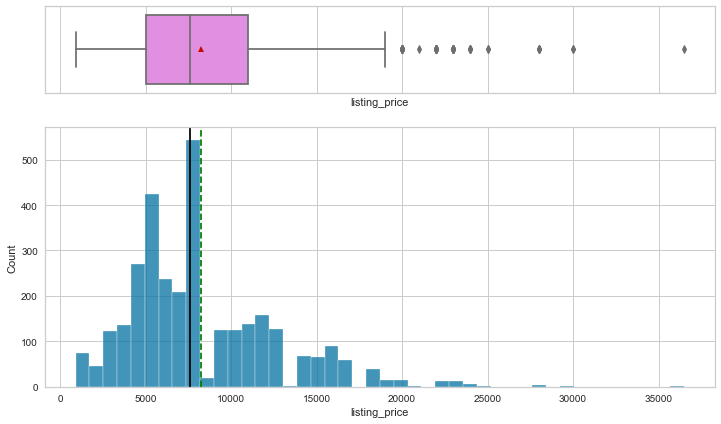

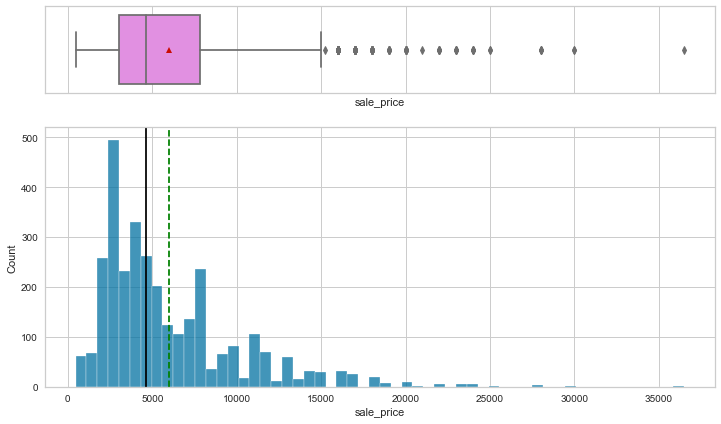

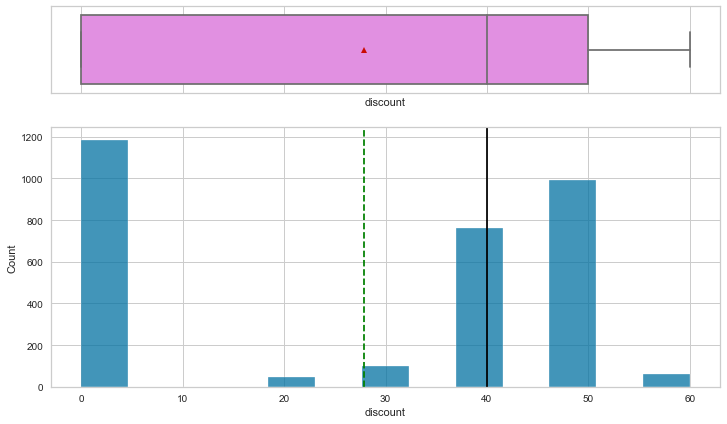

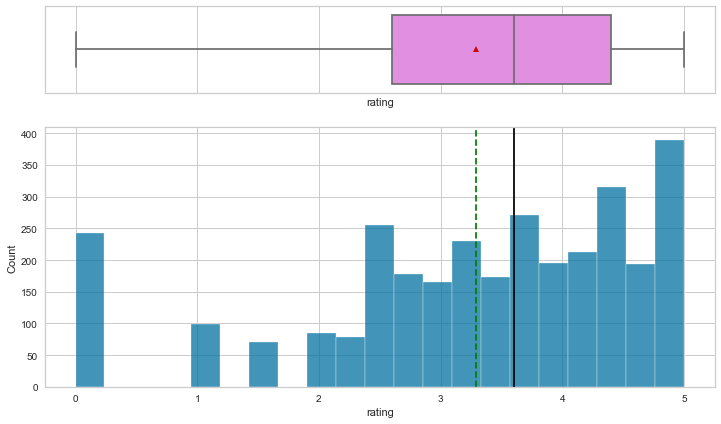

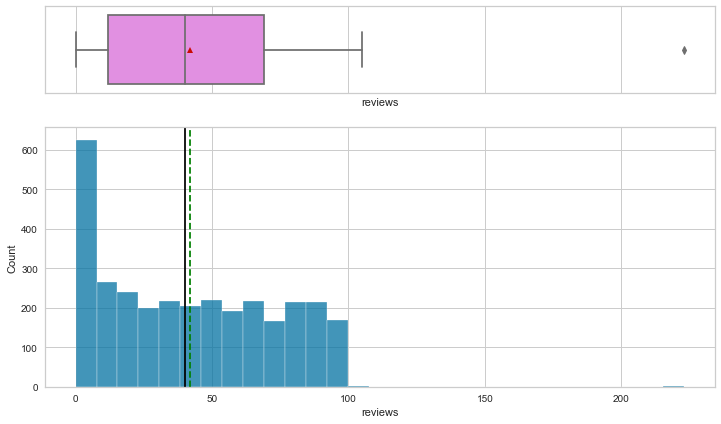

In [17]:
# function to plot a boxplot and a histogram along the same scale.


def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to the show density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram
# selecting numerical columns
num_col = df.select_dtypes(include=np.number).columns.tolist()

for item in num_col:
    histogram_boxplot(df, item)

- Listing price and sale price have right-skewed distributions with upper outliers, which indicates the presence of very expensive products.
- The maximum discount given is 60%.
- Rating is left-skewed and most of the ratings are between 2.5 and 4.5.
- The number of reviews is between 1 and 100, with an outlier value above 200.

In [18]:
#function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

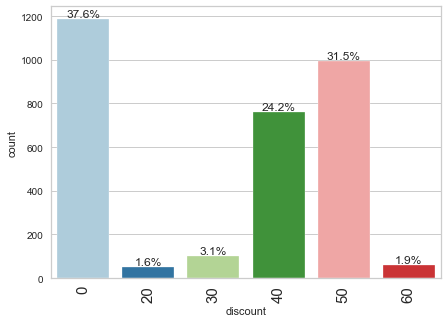

In [19]:
labeled_barplot(df, "discount", perc = True)

## Bivariate analysis

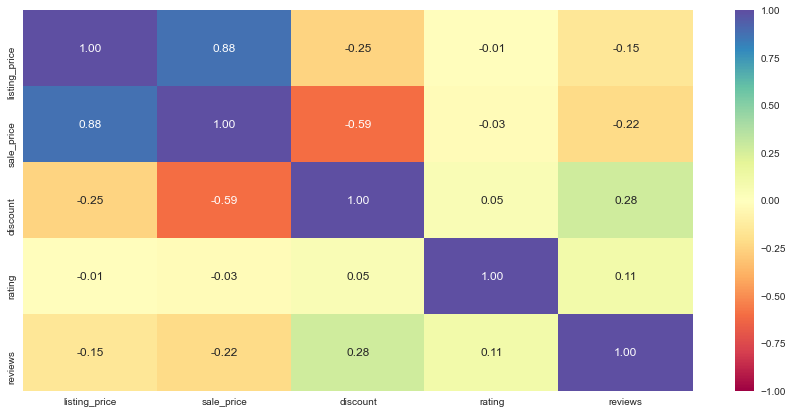

In [20]:
plt.figure(figsize=(15, 7))
sns.heatmap(df[num_col].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

#### observations

- The sale price and the listing price are highly positively correlated, which is obvious.
- Discount is somewhat negatively correlated with listing price or sale price, which indicates that expensive products either have fewer discounts or no discounts at all.

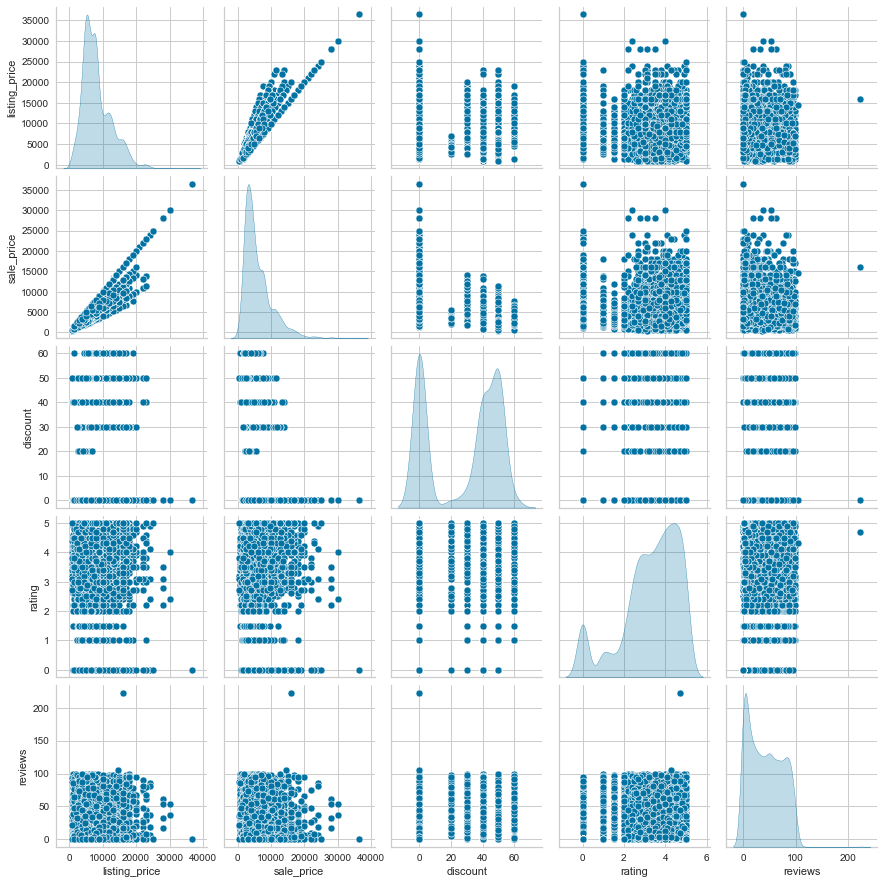

In [21]:
sns.pairplot(data=df[num_col], diag_kind="kde")
plt.show()

In [22]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
subset = df[num_col].copy()
subset_scaled = scaler.fit_transform(subset)

In [23]:
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

In [24]:
subset_scaled_df

,listing_price,sale_price,discount,rating,reviews
0,1.549271,0.363244,0.986622,1.104215,-0.028491
1,-0.147071,-0.523399,0.986622,0.010437,-0.571995
2,-1.660026,-1.290225,0.540973,-0.499993,-0.156374
3,-0.284613,-0.595289,0.986622,0.593785,-0.220316
4,-0.055377,-0.475472,0.986622,0.156274,0.962605
...,...,...,...,...,...
3146,-0.400147,0.122652,-1.241622,-2.395876,-1.339295
3147,1.319119,1.919900,-1.241622,-0.208319,-1.307324
3148,1.777590,1.632820,-1.241622,1.250052,-1.307324
3149,2.006826,2.638799,-1.241622,0.520867,-1.211412


## Kmean clustering

In [25]:
clusters = range(1,9)
mean_distortions = []

for k in clusters:
    model = KMeans(n_clusters=k)
    model.fit(subset_scaled_df)
    prediction = model.predict(subset_scaled_df)
    distortion = (
        sum(
            np.min(cdist(subset_scaled_df, model.cluster_centers_, "euclidean"), axis=1)
        )
        / subset_scaled_df.shape[0]
    )

    mean_distortions.append(distortion)
    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

Number of Clusters: 1 	Average Distortion: 2.0907211006458244
Number of Clusters: 2 	Average Distortion: 1.712012896274925
Number of Clusters: 3 	Average Distortion: 1.5555561011052423
Number of Clusters: 4 	Average Distortion: 1.4457273039154348
Number of Clusters: 5 	Average Distortion: 1.3083161318120873
Number of Clusters: 6 	Average Distortion: 1.2303194797652675
Number of Clusters: 7 	Average Distortion: 1.1631082749730368
Number of Clusters: 8 	Average Distortion: 1.10103847960754


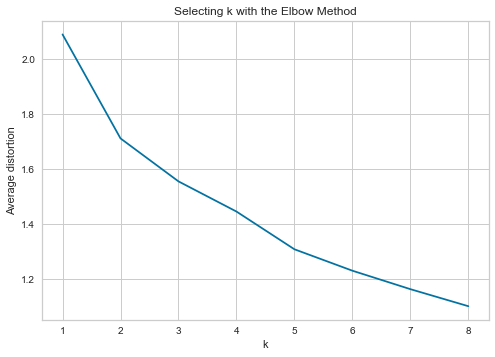

In [26]:
plt.plot(clusters, mean_distortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average distortion")
plt.title("Selecting k with the Elbow Method");

#### Appropriate value for k seems to be 3 or 4.

In [27]:
sil_score = []
cluster_list =list(range(2,10))

for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters = n_clusters)
    preds = clusterer.fit_predict(subset_scaled_df)
    
    score = silhouette_score(subset_scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))


For n_clusters = 2, the silhouette score is 0.33477783024143065)
For n_clusters = 3, the silhouette score is 0.2974036617212863)
For n_clusters = 4, the silhouette score is 0.3058963047486279)
For n_clusters = 5, the silhouette score is 0.27041626216723363)
For n_clusters = 6, the silhouette score is 0.28116616926896415)
For n_clusters = 7, the silhouette score is 0.29086054936328554)
For n_clusters = 8, the silhouette score is 0.2926830678403425)
For n_clusters = 9, the silhouette score is 0.28596595627677646)


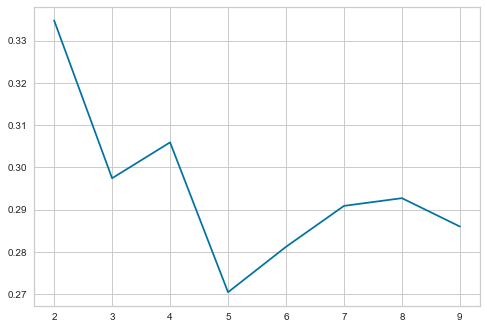

In [28]:
plt.plot(cluster_list, sil_score)

#### Silhouette score for 4 is higher than that for 3. So, we will choose 4 as value of k.


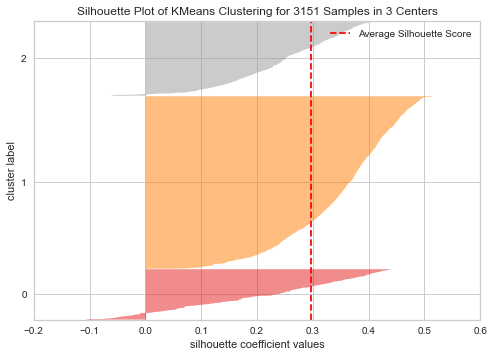

<AxesSubplot:title={'center':'Silhouette Plot of KMeans Clustering for 3151 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [29]:
visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

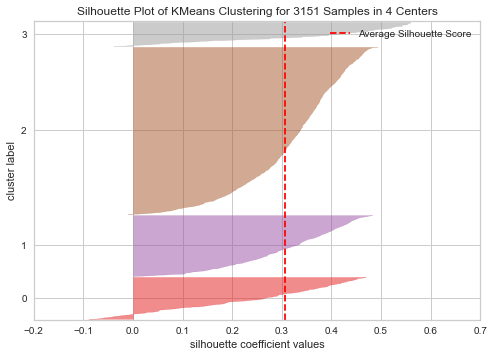

<AxesSubplot:title={'center':'Silhouette Plot of KMeans Clustering for 3151 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [30]:
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(subset_scaled_df)
visualizer.show()

In [31]:
kmeans = KMeans(n_clusters = 4, random_state=0)
kmeans.fit(subset_scaled_df)

KMeans(n_clusters=4, random_state=0)

In [32]:
df["K_means_segments"] = kmeans.labels_
subset_scaled_df["K_means_segments"] = kmeans.labels_

In [33]:
df.head()

,product_name,listing_price,sale_price,discount,brand,rating,reviews,K_means_segments
0,Women's adidas Originals NMD_Racer Primeknit S...,14999,7499,50,Adidas Adidas ORIGINALS,4.8,41,1
1,Women's adidas Originals Sleek Shoes,7599,3799,50,Adidas ORIGINALS,3.3,24,1
2,Women's adidas Swim Puka Slippers,999,599,40,Adidas CORE / NEO,2.6,37,1
3,Women's adidas Sport Inspired Questar Ride Shoes,6999,3499,50,Adidas CORE / NEO,4.1,35,1
4,Women's adidas Originals Taekwondo Shoes,7999,3999,50,Adidas ORIGINALS,3.5,72,1


### cluster profiling

In [34]:
cluster_profile = df.groupby(['K_means_segments']).mean()

In [35]:
cluster_profile["count_in_each_segments"] = (
    df.groupby("K_means_segments")["sale_price"].count().values
)

In [36]:
cluster_profile

,listing_price,sale_price,discount,rating,reviews,count_in_each_segments
K_means_segments,,,,,,
0,15557.331111,13424.604444,8.711111,3.928444,31.780000,450
1,6804.826331,3688.977031,45.462185,3.390924,50.151261,1785
2,9725.996255,8331.101124,7.715356,0.255805,11.898876,267
3,6505.070878,6167.425270,1.016949,3.797072,38.522342,649


In [37]:
cluster_profile.style.highlight_max()

,listing_price,sale_price,discount,rating,reviews,count_in_each_segments
K_means_segments,,,,,,
0,15557.331111,13424.604444,8.711111,3.928444,31.780000,450
1,6804.826331,3688.977031,45.462185,3.390924,50.151261,1785
2,9725.996255,8331.101124,7.715356,0.255805,11.898876,267
3,6505.070878,6167.425270,1.016949,3.797072,38.522342,649


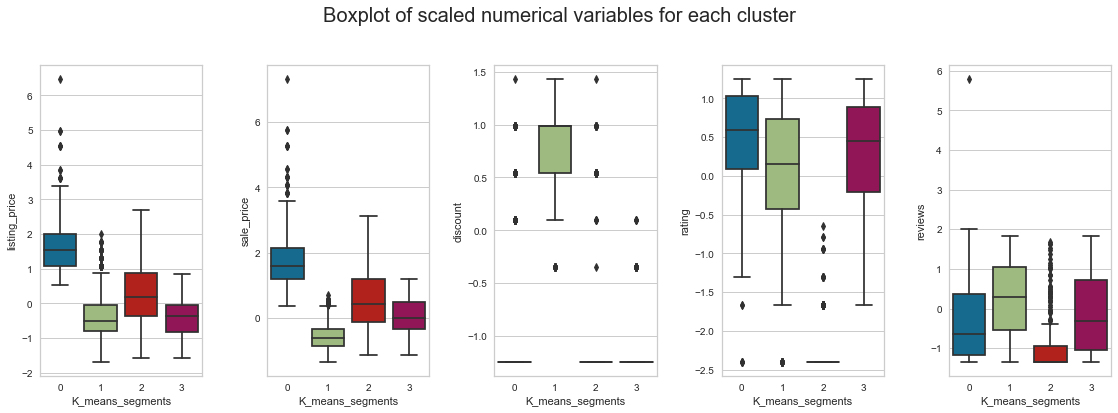

In [38]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of scaled numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(
        ax=axes[ii],
        y=subset_scaled_df[num_col[counter]],
        x=subset_scaled_df["K_means_segments"],
    )
    counter = counter + 1

fig.tight_layout(pad=2.0)

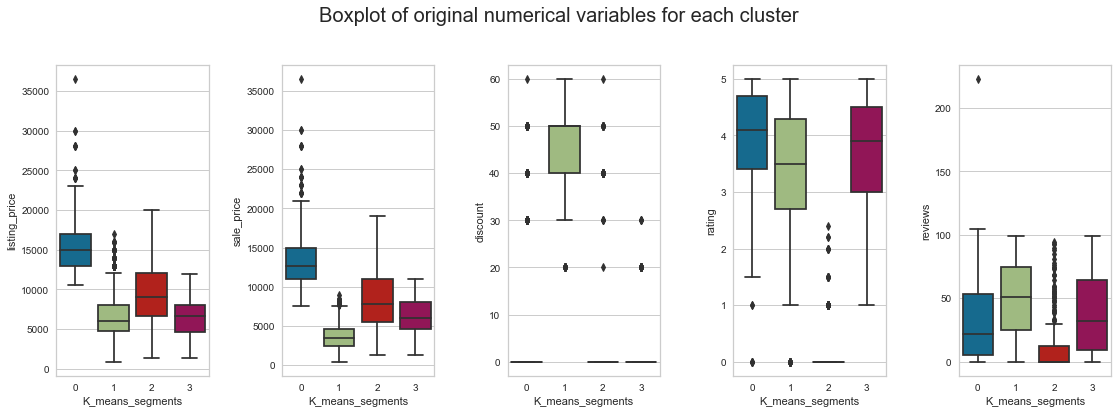

In [39]:
fig, axes = plt.subplots(1, 5, figsize=(16, 6))
fig.suptitle("Boxplot of original numerical variables for each cluster", fontsize=20)
counter = 0
for ii in range(5):
    sns.boxplot(ax=axes[ii], y=df[num_col[counter]], x=df["K_means_segments"])
    counter = counter + 1

fig.tight_layout(pad=2.0)

## Insights

1) Cluster 0:

- This cluster contains more expensive premium products, with an average listing price of approximately 15500
- Almost no discount is given to the shoes in this cluster
- Median rating is around 4, suggesting that customers are satisfied with 50% products in this category
- less no. of reviews indicate less sale as these are premiums shoes


2) Cluster 1:
- The listing price is on lower range from 5000 to 8000
- almost 40 to 50% discount is offered on these products
- the average rating stands somewhere around 3.5
- on an average 50 reviews are given to this product

3) Cluster 2
- The listing price suggest that these are medium priced shoes
- almost no discounts

4) Cluster 3
- The listing price of products in this cluster is similar to those in Cluster 1, but the sale price is comparatively higher as there are almost no discounts.
- On average, 38 reviews are given to products in this cluster 

In [40]:
pd.crosstab(df.K_means_segments, df.brand).style.highlight_max()

brand,Adidas Adidas ORIGINALS,Adidas CORE / NEO,Adidas ORIGINALS,Adidas SPORT PERFORMANCE,Nike
K_means_segments,,,,,
0,0,0,133,128,189
1,1,864,564,356,0
2,0,18,53,23,173
3,0,229,156,99,165


- nike hardly offers any discount
- 1/3 of nike products are premium

## Business recommendations

- Cluster 0 consists of premium products, so focused marketing campaigns can be done to target customers with higher purchasing power.

- Cluster 1 and 3 consists of products with comparatively low and medium prices with almost no discount, so general marketing campaigns can be done for these to target the general public.

- Cluster 2 consists of products that are sold at higher discounts, so these might be the ones that are introduced in large quantity during festive sales (like Christmas, Black Friday, New Year, etc). This strategy can be continued with high inventory.